In [ ]:
import numpy as np
import pandas as pd
import optuna
import joblib
import sys
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from catboost import CatBoostClassifier
from tqdm.notebook import tqdm
from Auxiliary_elements import to_num_nbin, to_delete

In [ ]:
PROJECT_ROOT = Path().resolve().parent  
sys.path.append(str(PROJECT_ROOT))

In [ ]:
binary_column = ["gender", "SeniorCitizen", "Partner", 
                 "Dependents", "PhoneService", "PaperlessBilling",
                ]
to_binary_column = ["MultipleLines", "OnlineSecurity", "OnlineBackup",
                    "DeviceProtection", "TechSupport", "StreamingTV",
                    "StreamingMovies",
                ]
cat_column = ["remainder__InternetService", "remainder__Contract", 
              "remainder__PaymentMethod",
            ]

model = CatBoostClassifier(cat_features=tuple(cat_column), verbose=0, auto_class_weights="Balanced")

preprocess = ColumnTransformer(transformers=[
    ("to_num_bin", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), binary_column),
    ("to_num_nbin", FunctionTransformer(to_num_nbin), to_binary_column),
], remainder='passthrough')

preprocess.set_output(transform="pandas")
pipeline = Pipeline([
    ("to_delete", FunctionTransformer(to_delete)),
    ("preprocess", preprocess),
    ("model", model),
])

In [12]:
df = pd.read_csv('../Data/Telco-Customer-Churn.csv')

In [13]:
from sklearn.model_selection import train_test_split

X = df.drop(["Churn"], axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.12, random_state=42)

In [ ]:
def objective(trial):
    params = {
        "model__n_estimators": trial.suggest_int("n_estimators", 50, 500),
        "model__max_depth" : trial.suggest_int("max_depth", 2, 10),
        "model__learning_rate" : trial.suggest_float("learning_rate", 1e-4, 0.3, log=True),
        "model__subsample": trial.suggest_float("subsample", 0.5, 1.0),
    }

    pipeline.set_params(**params)
    score = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="accuracy").mean()
    return score

pbar = tqdm(total=25, desc='Optuna tuning')

def tqdm_call_back(study, trial):
    pbar.update(1)
    pbar.set_postfix(best_score=f"{study.best_value:.4f}")

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=25, callbacks=[tqdm_call_back])


Optuna tuning:   0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-07-04 09:35:21,592] A new study created in memory with name: no-name-96333187-85d7-4f7c-9a6b-429424cfbf58
[I 2026-07-04 09:35:27,804] Trial 0 finished with value: 0.7365938229313456 and parameters: {'n_estimators': 174, 'max_depth': 2, 'learning_rate': 0.02686623262962688, 'subsample': 0.9847013147543845}. Best is trial 0 with value: 0.7365938229313456.
[I 2026-07-04 09:35:51,655] Trial 1 finished with value: 0.7598659010086156 and parameters: {'n_estimators': 160, 'max_depth': 10, 'learning_rate': 0.03756951310341867, 'subsample': 0.6356379737590437}. Best is trial 1 with value: 0.7598659010086156.
[I 2026-07-04 09:36:49,312] Trial 2 finished with value: 0.7640629591368977 and parameters: {'n_estimators': 379, 'max_depth': 10, 'learning_rate': 0.028856134221225654, 'subsample': 0.7119582951806677}. Best is trial 2 with value: 0.7640629591368977.
[I 2026-07-04 09:37:24,354] Trial 3 finished with value: 0.7454814725814056 and parameters: {'n_estimators': 409, 'max_depth': 6, 'le

In [15]:
study.best_params
params={
        "model__n_estimators": study.best_params["n_estimators"],
        "model__max_depth" :study.best_params["max_depth"],
        "model__learning_rate" : study.best_params["learning_rate"],
        "model__subsample": study.best_params["subsample"],
    }

In [16]:
model = pipeline.set_params(**params)

In [17]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('to_delete', ...), ('preprocess', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['customerID','gender','SeniorCitizen',...,'PaymentMethod', 'MonthlyCharges','TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function to_...001F046DF3C40>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False


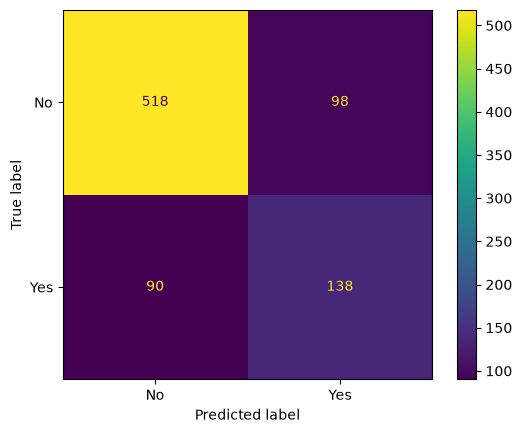

In [19]:
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

In [20]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.85      0.84      0.85       616
         Yes       0.58      0.61      0.59       228

    accuracy                           0.78       844
   macro avg       0.72      0.72      0.72       844
weighted avg       0.78      0.78      0.78       844



In [ ]:
with open("../model/model.joblib", "wb") as f:
    joblib.dump(model, f)